# TFTIS Gas-Mixture Dataset and Analysis

This notebook reproduces the feature-extraction and PCA analysis workflow for the initial TFTIS ethanol–acetone gas-mixture dataset.

The dataset and associated analysis resources are hosted in the public TFTIS GitHub repository:

https://github.com/engrhamzaaliimran/tftis.git

Cloning the dataset

In [1]:
# Clone the TFTIS GitHub repository
!git clone https://github.com/engrhamzaaliimran/tftis.git

# Define the dataset ZIP path
data_zip = "/content/tftis/mixtures-data.zip"

# Check that it was downloaded correctly
import os
print("Dataset ZIP found:", os.path.exists(data_zip))
print("Dataset path:", data_zip)

Cloning into 'tftis'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 15.78 MiB | 28.11 MiB/s, done.
Dataset ZIP found: True
Dataset path: /content/tftis/mixtures-data.zip


The subsequent cells extract the 12-dimensional exponentially modified Gaussian (EMG) feature representation from the dense impedance measurements

In [2]:
%%writefile extract_emg_dense_features_only.py


#!/usr/bin/env python3
"""
Extract dense 12D EMG features from EIS HDF5 files.

This script do following:
1. Finds and inventories parseable HDF5 files.
2. Fits the EMG four-parameter EMG model to Z'' at 150, 250, and 350 °C.
3. Saves the sweep-level 12D feature dataset and detailed fit-quality table.


---------
Steps it does:
- Z'' = -magnitude * sin(phase)
- x = log10(frequency)
- Fit EMG Model and return: amp, mu, sigma, lambda

Expected input structure:
data/
  E001ppm_A004ppm/
    T150C/E001ppm_A004ppm_T150C_M010_20251218_115625.h5
    T250C/...
    T350C/...

Example Usage:
python extract_emg_dense_features_only.py \
  --input mixtures-data.zip \
  --out emg_feature_dataset
"""

from __future__ import annotations

import argparse
import re
import shutil
import tempfile
import zipfile
from pathlib import Path
from typing import Dict, List, Tuple

import h5py
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import erfc


FNAME_RE = re.compile(
    r"E(?P<eth>\d{3})ppm_A(?P<ace>\d{3})ppm_T(?P<temp>\d{3})C_"
    r"M(?P<meas>\d{3})_(?P<stamp>\d{8}_\d{6})\.h5$",
    re.IGNORECASE,
)

REQUIRED_TEMPS = [150, 250, 350]
FEATURE_NAMES = ["A", "mu", "sigma", "lambda"]


# ---------------------------------------------------------------------
# EMG fitting copied/matched from zComplex_EMG_individual_sweeps_data_extraction_robust_v4.py
# ---------------------------------------------------------------------

def emg(x: np.ndarray, amp: float, mu: float, sigma: float, lam: float) -> np.ndarray:
    return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
           erfc((mu + lam * sigma**2 - x) / (np.sqrt(2) * sigma))


def compute_imaginary_impedance(magnitude: np.ndarray, phase: np.ndarray) -> np.ndarray:
    # phase expected in radians
    return -magnitude * np.sin(phase)


def r2_score_emg(y: np.ndarray, yfit: np.ndarray) -> float:
    ss_res = np.sum((y - yfit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan


def initial_guess_and_bounds(x: np.ndarray, y: np.ndarray):
    if len(x) == 0 or len(y) == 0 or not np.isfinite(np.nanmax(y)):
        A0 = 1.0
        mu0 = float(np.median(x)) if len(x) else 0.0
    else:
        idx_max = int(np.nanargmax(y))
        Amax = float(np.nanmax(y))
        A0 = Amax if Amax > 0 else 1.0
        mu0 = float(x[idx_max]) if np.isfinite(x[idx_max]) else float(np.nanmedian(x))

    sigma0 = 0.25
    lam0 = 1.0
    x_min = float(np.nanmin(x)) if len(x) else -2.0
    x_max = float(np.nanmax(x)) if len(x) else 8.0
    lower = [0.0, x_min - 1.0, 1e-3, 1e-3]
    amp_upper = (A0 * 10.0) if np.isfinite(A0) and A0 > 0 else 1e6
    upper = [amp_upper, x_max + 1.0, 2.0, 50.0]
    return [A0, mu0, sigma0, lam0], (lower, upper)


def fit_emg_single_sweep(freq_1d: np.ndarray, z_imag_1d: np.ndarray):
    mask = np.isfinite(freq_1d) & (freq_1d > 0) & np.isfinite(z_imag_1d)
    x = np.log10(freq_1d[mask])
    y = z_imag_1d[mask]

    if len(x) < 10 or not np.isfinite(np.nanmax(y)) or np.nanmax(y) <= 0:
        return (False, *(np.nan,) * 4, np.nan)

    p0, bounds = initial_guess_and_bounds(x, y)
    try:
        popt, _ = curve_fit(emg, x, y, p0=p0, bounds=bounds, maxfev=20000)
        yfit = emg(x, *popt)
        return (
            True,
            float(popt[0]),
            float(popt[1]),
            float(popt[2]),
            float(popt[3]),
            r2_score_emg(y, yfit),
        )
    except Exception:
        return (False, *(np.nan,) * 4, np.nan)


# ---------------------------------------------------------------------
# Dataset handling and feature extraction only
# ---------------------------------------------------------------------

def prepare_input(input_path: Path) -> Tuple[Path, tempfile.TemporaryDirectory | None]:
    input_path = input_path.expanduser().resolve()
    if input_path.is_dir():
        if (input_path / "data").is_dir():
            return input_path / "data", None
        return input_path, None

    if input_path.is_file() and input_path.suffix.lower() == ".zip":
        tmp = tempfile.TemporaryDirectory()
        with zipfile.ZipFile(input_path, "r") as zf:
            zf.extractall(tmp.name)
        root = Path(tmp.name)
        if (root / "data").is_dir():
            return root / "data", tmp
        data_dirs = [p for p in root.rglob("data") if p.is_dir()]
        if data_dirs:
            return data_dirs[0], tmp
        return root, tmp

    raise FileNotFoundError(f"Unsupported input: {input_path}")


def parse_inventory(data_root: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(data_root.rglob("*.h5")):
        m = FNAME_RE.match(p.name)
        if not m:
            print(f"[WARN] Skipping unparsed file name: {p}")
            continue
        eth = int(m.group("eth"))
        ace = int(m.group("ace"))
        temp = int(m.group("temp"))
        meas = int(m.group("meas"))
        rows.append({
            "condition_id": f"E{eth:03d}ppm_A{ace:03d}ppm",
            "ethanol_ppm": float(eth),
            "acetone_ppm": float(ace),
            "temperature_C": temp,
            "measurement": meas,
            "timestamp": m.group("stamp"),
            "path": str(p),
        })
    if not rows:
        raise RuntimeError("No parseable H5 files found. Check filename format.")
    return pd.DataFrame(rows)


def get_complete_conditions(files_df: pd.DataFrame) -> List[str]:
    complete = []
    required = set(REQUIRED_TEMPS)
    for cid, g in files_df.groupby("condition_id"):
        if required.issubset(set(g["temperature_C"])):
            complete.append(cid)
    return complete


def load_h5_arrays(path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    with h5py.File(path, "r") as h5:
        f = np.asarray(h5["frequency"])
        mag = np.asarray(h5["magnitude"])
        ph = np.asarray(h5["phase"])
    if f.ndim == 1:
        f = f[None, :]
        mag = mag[None, :]
        ph = ph[None, :]
    return f, mag, ph


def extract_features(files_df: pd.DataFrame, out_dir: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    complete_conditions = get_complete_conditions(files_df)
    files_df_complete = files_df[files_df["condition_id"].isin(complete_conditions)].copy()

    feature_rows = []
    fit_rows = []

    for cid in complete_conditions:
        gcond = files_df_complete[files_df_complete["condition_id"] == cid]
        meta = gcond.iloc[0]

        temp_data: Dict[int, dict] = {}
        for temp in REQUIRED_TEMPS:
            # Kept exactly as in the original script: use the first matching file
            # when more than one file exists for a condition/temperature.
            row = gcond[gcond["temperature_C"] == temp].iloc[0]
            f, mag, ph = load_h5_arrays(row["path"])
            z = compute_imaginary_impedance(mag, ph)
            temp_data[temp] = {"f": f, "z": z, "path": row["path"], "n_sweeps": f.shape[0]}

        n_sweeps = min(temp_data[t]["n_sweeps"] for t in REQUIRED_TEMPS)
        print(f"[INFO] {cid}: using {n_sweeps} aligned sweeps")

        for si in range(n_sweeps):
            feat = {
                "condition_id": cid,
                "ethanol_ppm": float(meta["ethanol_ppm"]),
                "acetone_ppm": float(meta["acetone_ppm"]),
                "sweep_index": si,
            }

            min_r2 = np.inf
            ok_all = True

            for temp in REQUIRED_TEMPS:
                f = temp_data[temp]["f"][si]
                z = temp_data[temp]["z"][si]

                ok, A, mu, sigma, lam, r2 = fit_emg_single_sweep(f, z)

                feat[f"T{temp}_A"] = A
                feat[f"T{temp}_mu"] = mu
                feat[f"T{temp}_sigma"] = sigma
                feat[f"T{temp}_lambda"] = lam

                fit_rows.append({
                    "condition_id": cid,
                    "ethanol_ppm": float(meta["ethanol_ppm"]),
                    "acetone_ppm": float(meta["acetone_ppm"]),
                    "sweep_index": si,
                    "temperature_C": temp,
                    "A": A,
                    "mu": mu,
                    "sigma": sigma,
                    "lambda": lam,
                    "r2": r2,
                    "fit_ok": bool(ok),
                    "source_path": temp_data[temp]["path"],
                })

                if ok and np.isfinite(r2):
                    min_r2 = min(min_r2, r2)
                else:
                    ok_all = False

            feat["min_fit_r2"] = min_r2 if np.isfinite(min_r2) else np.nan
            feat["all_fit_ok"] = ok_all
            feature_rows.append(feat)

    features_df = pd.DataFrame(feature_rows)
    fit_df = pd.DataFrame(fit_rows)

    # Main machine-learning-ready sweep-level dataset, unchanged from the original pipeline.
    features_df.to_csv(out_dir / "dense_full_EMG_12D_sweep_features.csv", index=False)

    # Detailed quality log for every temperature-specific EMG fit.
    fit_df.to_csv(out_dir / "dense_full_EMG_fit_quality_long.csv", index=False)

    return features_df, fit_df


def main() -> None:
    parser = argparse.ArgumentParser(
        description="Extract dense 12D EMG sweep-level features from HDF5 files; no ML is run."
    )
    parser.add_argument(
        "--input",
        required=True,
        help="Clean data folder, parent folder, or ZIP containing data/."
    )
    parser.add_argument(
        "--out",
        default="emg_dense_feature_dataset",
        help="Output folder for the extracted CSV files."
    )
    args = parser.parse_args()

    out_dir = Path(args.out).expanduser().resolve()
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    data_root, tmp = prepare_input(Path(args.input))

    try:
        print(f"[INFO] Data root: {data_root}")
        files_df = parse_inventory(data_root)
        files_df.to_csv(out_dir / "input_file_inventory.csv", index=False)

        complete = get_complete_conditions(files_df)
        print(f"[INFO] Parsed H5 files: {len(files_df)}")
        print(f"[INFO] Complete 3-temperature conditions: {len(complete)}")

        features_df, fit_df = extract_features(files_df, out_dir)

        print(f"[INFO] Sweep-level feature table: {features_df.shape}")
        print(f"[INFO] Fit success rate: {features_df['all_fit_ok'].mean():.2%}")
        print(f"[INFO] Mean minimum EMG R2: {features_df['min_fit_r2'].mean():.5f}")
        print(f"[INFO] Main feature dataset: {out_dir / 'dense_full_EMG_12D_sweep_features.csv'}")
        print(f"[INFO] Fit-quality log: {out_dir / 'dense_full_EMG_fit_quality_long.csv'}")
        print(f"\n[DONE] Feature extraction completed. Files saved to: {out_dir}")

    finally:
        if tmp is not None:
            tmp.cleanup()


if __name__ == "__main__":
    main()


Writing extract_emg_dense_features_only.py


In [4]:
!python extract_emg_dense_features_only.py \
  --input tftis/mixtures-data.zip \
  --out emg_feature_dataset

[INFO] Data root: /tmp/tmpezcgutpv/data
[INFO] Parsed H5 files: 36
[INFO] Complete 3-temperature conditions: 12
[INFO] E001ppm_A004ppm: using 37 aligned sweeps
[INFO] E001ppm_A008ppm: using 37 aligned sweeps
[INFO] E001ppm_A016ppm: using 38 aligned sweeps
[INFO] E002ppm_A004ppm: using 38 aligned sweeps
[INFO] E002ppm_A008ppm: using 38 aligned sweeps
[INFO] E002ppm_A016ppm: using 38 aligned sweeps
[INFO] E003ppm_A004ppm: using 37 aligned sweeps
/content/extract_emg_dense_features_only.py:64: RuntimeWarning: overflow encountered in exp
  return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
/content/extract_emg_dense_features_only.py:64: RuntimeWarning: overflow encountered in multiply
  return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
/content/extract_emg_dense_features_only.py:64: RuntimeWarning: invalid value encountered in multiply
  return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
[INFO]

The following cells, generate the PCA visualization of ethanol–acetone mixture structure.

In [5]:
!ls "/content/emg_feature_dataset/dense_full_EMG_12D_sweep_features.csv"

/content/emg_feature_dataset/dense_full_EMG_12D_sweep_features.csv


In [6]:
%%writefile pca_emg12_mixtures_simple_ethanol_ellips.py

#!/usr/bin/env python3
"""
Clean PCA plot for 12D EMG mixture features.

This script makes only one figure:
    PCA of 12D EMG features: ethanol background structure

Visual encoding:
    x-axis  = PC1 score
    y-axis  = PC2 score
    color   = ethanol background concentration
    marker  = target acetone concentration
    ellipse = covariance ellipse for each ethanol background group

Example:
python pca_emg12_mixtures_simple_ethanol_ellips.py \
    --features-csv dense_full_EMG_12D_sweep_features.csv \
    --out-png MIXTURE_PCA_2D_ethanol_color_acetone_marker_clean.png
"""

from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def save_figure_all_formats(fig, out_png: Path, dpi: int = 300) -> None:
    """
    Save figure as PNG, EPS, and PDF using the same base filename.

    Example:
        figure.png
        figure.eps
        figure.pdf
    """
    out_png = Path(out_png)

    fig.savefig(out_png.with_suffix(".png"), dpi=dpi, bbox_inches="tight")
    fig.savefig(out_png.with_suffix(".eps"), format="eps", bbox_inches="tight")
    fig.savefig(out_png.with_suffix(".pdf"), format="pdf", bbox_inches="tight")

# ---------------------------------------------------------------------
# 1. Feature definition
# ---------------------------------------------------------------------

TEMPS = [150, 250, 350]
FEATURES = ["A", "mu", "sigma", "lambda"]


def feature_columns() -> list[str]:
    """Return the required 12 EMG feature columns."""
    return [f"T{temp}_{feat}" for temp in TEMPS for feat in FEATURES]


# ---------------------------------------------------------------------
# 2. Plot style maps
# ---------------------------------------------------------------------

ETHANOL_COLORS = {
    # 1.0: "#9467bd",   # purple
    # 2.0: "#8c564b",   # brown
    # 3.0: "#e377c2",   # pink
    # 6.0: "#7f7f7f",   # gray

    1.0: "#A7D8FF",   # light but visible blue
    2.0: "#3399FF",   # bright blue
    3.0: "#005BBB",   # dark blue
    6.0: "#001A4D",   # deepest navy

}

ACETONE_MARKERS = {
    4.0: "o",   # circle
    8.0: "s",   # square
    16.0: "^",  # triangle
}


# ---------------------------------------------------------------------
# 3. Data preparation
# --------------------------------------about:blank#blocked-------------------------------

def check_required_columns(df: pd.DataFrame, required_cols: list[str]) -> None:
    """Stop with a clear error if expected columns are missing."""
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def clean_data(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Keep only valid EMG rows and numeric mixture labels."""
    work = df.copy()

    # Optional column from the EMG fitting pipeline.
    # If available, keep only rows where all EMG fits were successful.
    if "all_fit_ok" in work.columns:
        work = work[work["all_fit_ok"] == True].copy()

    # Remove rows with NaN or infinite feature values.
    for col in feature_cols:
        work = work[np.isfinite(work[col])].copy()

    # Required metadata for this specific plot.
    required_metadata = ["ethanol_ppm", "acetone_ppm"]
    check_required_columns(work, required_metadata)

    work["ethanol_ppm"] = work["ethanol_ppm"].astype(float)
    work["acetone_ppm"] = work["acetone_ppm"].astype(float)

    return work.reset_index(drop=True)


# ---------------------------------------------------------------------
# 4. PCA
# ---------------------------------------------------------------------

def compute_pca_scores(work: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Standardize the 12D EMG features and compute PC1 and PC2.

    Returns
    -------
    scores_df:
        Original cleaned table plus PC1 and PC2 columns.
    explained_percent:
        Explained variance percentages for PC1 and PC2.
    """
    X = work[feature_cols].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=0)
    scores = pca.fit_transform(X_scaled)

    scores_df = work.copy()
    scores_df["PC1"] = scores[:, 0]
    scores_df["PC2"] = scores[:, 1]

    explained_percent = pca.explained_variance_ratio_ * 100.0
    return scores_df, explained_percent


# ---------------------------------------------------------------------
# 5. Covariance ellipse
# ---------------------------------------------------------------------

def covariance_ellipse_parameters(x: np.ndarray, y: np.ndarray, n_std: float = 1.5):
    """
    Calculate ellipse width, height, and rotation from PC1-PC2 covariance.

    The ellipse is centered later at the group mean.
    The width and height are full diameters, not radii.
    """
    if len(x) < 3:
        return None

    cov = np.cov(x, y)
    if not np.all(np.isfinite(cov)):
        return None

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    if np.any(eigenvalues <= 0):
        return None

    # Sort so the largest eigenvalue is first.
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Angle of the major axis.
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    # Matplotlib Ellipse expects full width and height.
    width, height = 2.0 * n_std * np.sqrt(eigenvalues)

    return width, height, angle


def add_covariance_ellipse(ax, x, y, color: str, n_std: float = 1.5) -> None:
    """Add a semi-transparent covariance ellipse to the plot."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    params = covariance_ellipse_parameters(x, y, n_std=n_std)
    if params is None:
        return

    width, height, angle = params

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=0.12,
        lw=1.5,
    )
    ax.add_patch(ellipse)


# ---------------------------------------------------------------------
# 6. Plot
# ---------------------------------------------------------------------

def make_ethanol_background_pca_plot(
    scores: pd.DataFrame,
    explained_percent: np.ndarray,
    out_png: Path,
    show_ellipses: bool = True,
) -> None:
    """Create the final PCA plot only."""
    fig, ax = plt.subplots(figsize=(8.2, 6.2))

    ethanol_values = sorted(scores["ethanol_ppm"].unique())
    acetone_values = sorted(scores["acetone_ppm"].unique())

    # Scatter points: color = ethanol background, marker = acetone concentration.
    for ethanol in ethanol_values:
        ethanol = float(ethanol)
        color = ETHANOL_COLORS.get(ethanol, "black")

        for acetone in acetone_values:
            acetone = float(acetone)
            marker = ACETONE_MARKERS.get(acetone, "D")

            sub = scores[
                (scores["ethanol_ppm"] == ethanol) &
                (scores["acetone_ppm"] == acetone)
            ]

            if sub.empty:
                continue

            ax.scatter(
                sub["PC1"],
                sub["PC2"],
                s=120,
                marker=marker,
                color=color,
                edgecolor="black",
                linewidth=0.35,
                alpha=0.82,
            )

        # One covariance ellipse per ethanol background concentration.
        if show_ellipses:
            sub_ethanol = scores[scores["ethanol_ppm"] == ethanol]
            add_covariance_ellipse(
                ax,
                sub_ethanol["PC1"],
                sub_ethanol["PC2"],
                color=color,
                n_std=1.5,
            )

    ax.set_xlabel(f"PC1 ({explained_percent[0]:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({explained_percent[1]:.1f}%)", fontsize=12)
    ax.set_title("PCA of Dense-EMG 12D EMG features: ethanol interference structure", fontsize=13)
    ax.grid(False)

    # Legend 1: ethanol colors.
    ethanol_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=ETHANOL_COLORS.get(float(ethanol), "black"),
            label=f"Ethanol {int(float(ethanol))} ppm",
            markersize=8,
        )
        for ethanol in ethanol_values
    ]

    # Legend 2: acetone markers.
    acetone_handles = [
        Line2D(
            [0], [0],
            marker=ACETONE_MARKERS.get(float(acetone), "D"),
            linestyle="",
            color="black",
            markerfacecolor="white",
            label=f"Acetone {int(float(acetone))} ppm",
            markersize=8,
        )
        for acetone in acetone_values
    ]

    legend1 = ax.legend(
        handles=ethanol_handles,
        title="Color = ethanol interference",
        loc="upper right",
        frameon=True,
    )
    ax.add_artist(legend1)

    ax.legend(
        handles=acetone_handles,
        title="Marker = target acetone",
        loc="lower right",
        frameon=True,
    )

    fig.tight_layout()
    #fig.savefig(out_png, dpi=300, bbox_inches="tight")
    save_figure_all_formats(fig, out_png, dpi=300)
    plt.close(fig)


# ---------------------------------------------------------------------
# 7. Main command-line entry point
# ---------------------------------------------------------------------

def main() -> None:
    parser = argparse.ArgumentParser(
        description="Create only the ethanol-background PCA plot from 12D EMG features."
    )
    parser.add_argument(
        "--features-csv",
        required=True,
        help="Input CSV containing 12D EMG features and ethanol_ppm / acetone_ppm columns.",
    )
    parser.add_argument(
        "--out-png",
        default="MIXTURE_PCA_2D_ethanol_color_acetone_marker_clean.png",
        help="Output PNG filename.",
    )
    parser.add_argument(
        "--no-ellipses",
        action="store_true",
        help="Disable ethanol-background covariance ellipses.",
    )
    args = parser.parse_args()

    input_csv = Path(args.features_csv)
    out_png = Path(args.out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)

    feature_cols = feature_columns()

    df = pd.read_csv(input_csv)
    check_required_columns(df, feature_cols)

    work = clean_data(df, feature_cols)
    scores, explained_percent = compute_pca_scores(work, feature_cols)

    make_ethanol_background_pca_plot(
        scores=scores,
        explained_percent=explained_percent,
        out_png=out_png,
        show_ellipses=not args.no_ellipses,
    )

    print(f"[DONE] Saved PCA plot to: {out_png.resolve()}")
    print(f"[INFO] PC1 explained variance: {explained_percent[0]:.2f}%")
    print(f"[INFO] PC2 explained variance: {explained_percent[1]:.2f}%")


if __name__ == "__main__":
    main()


Writing pca_emg12_mixtures_simple_ethanol_ellips.py


In [12]:
!python pca_emg12_mixtures_simple_ethanol_ellips.py \
  --features-csv "/content/emg_feature_dataset/dense_full_EMG_12D_sweep_features.csv" \
  --out-png "/content/MIXTURE_PCA_2D_ethanol_color_acetone_marker_clean.png"

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
[DONE] Saved PCA plot to: /content/MIXTURE_PCA_2D_ethanol_color_acetone_marker_clean.png
[INFO] PC1 explained variance: 55.42%
[INFO] PC2 explained variance: 16.19%


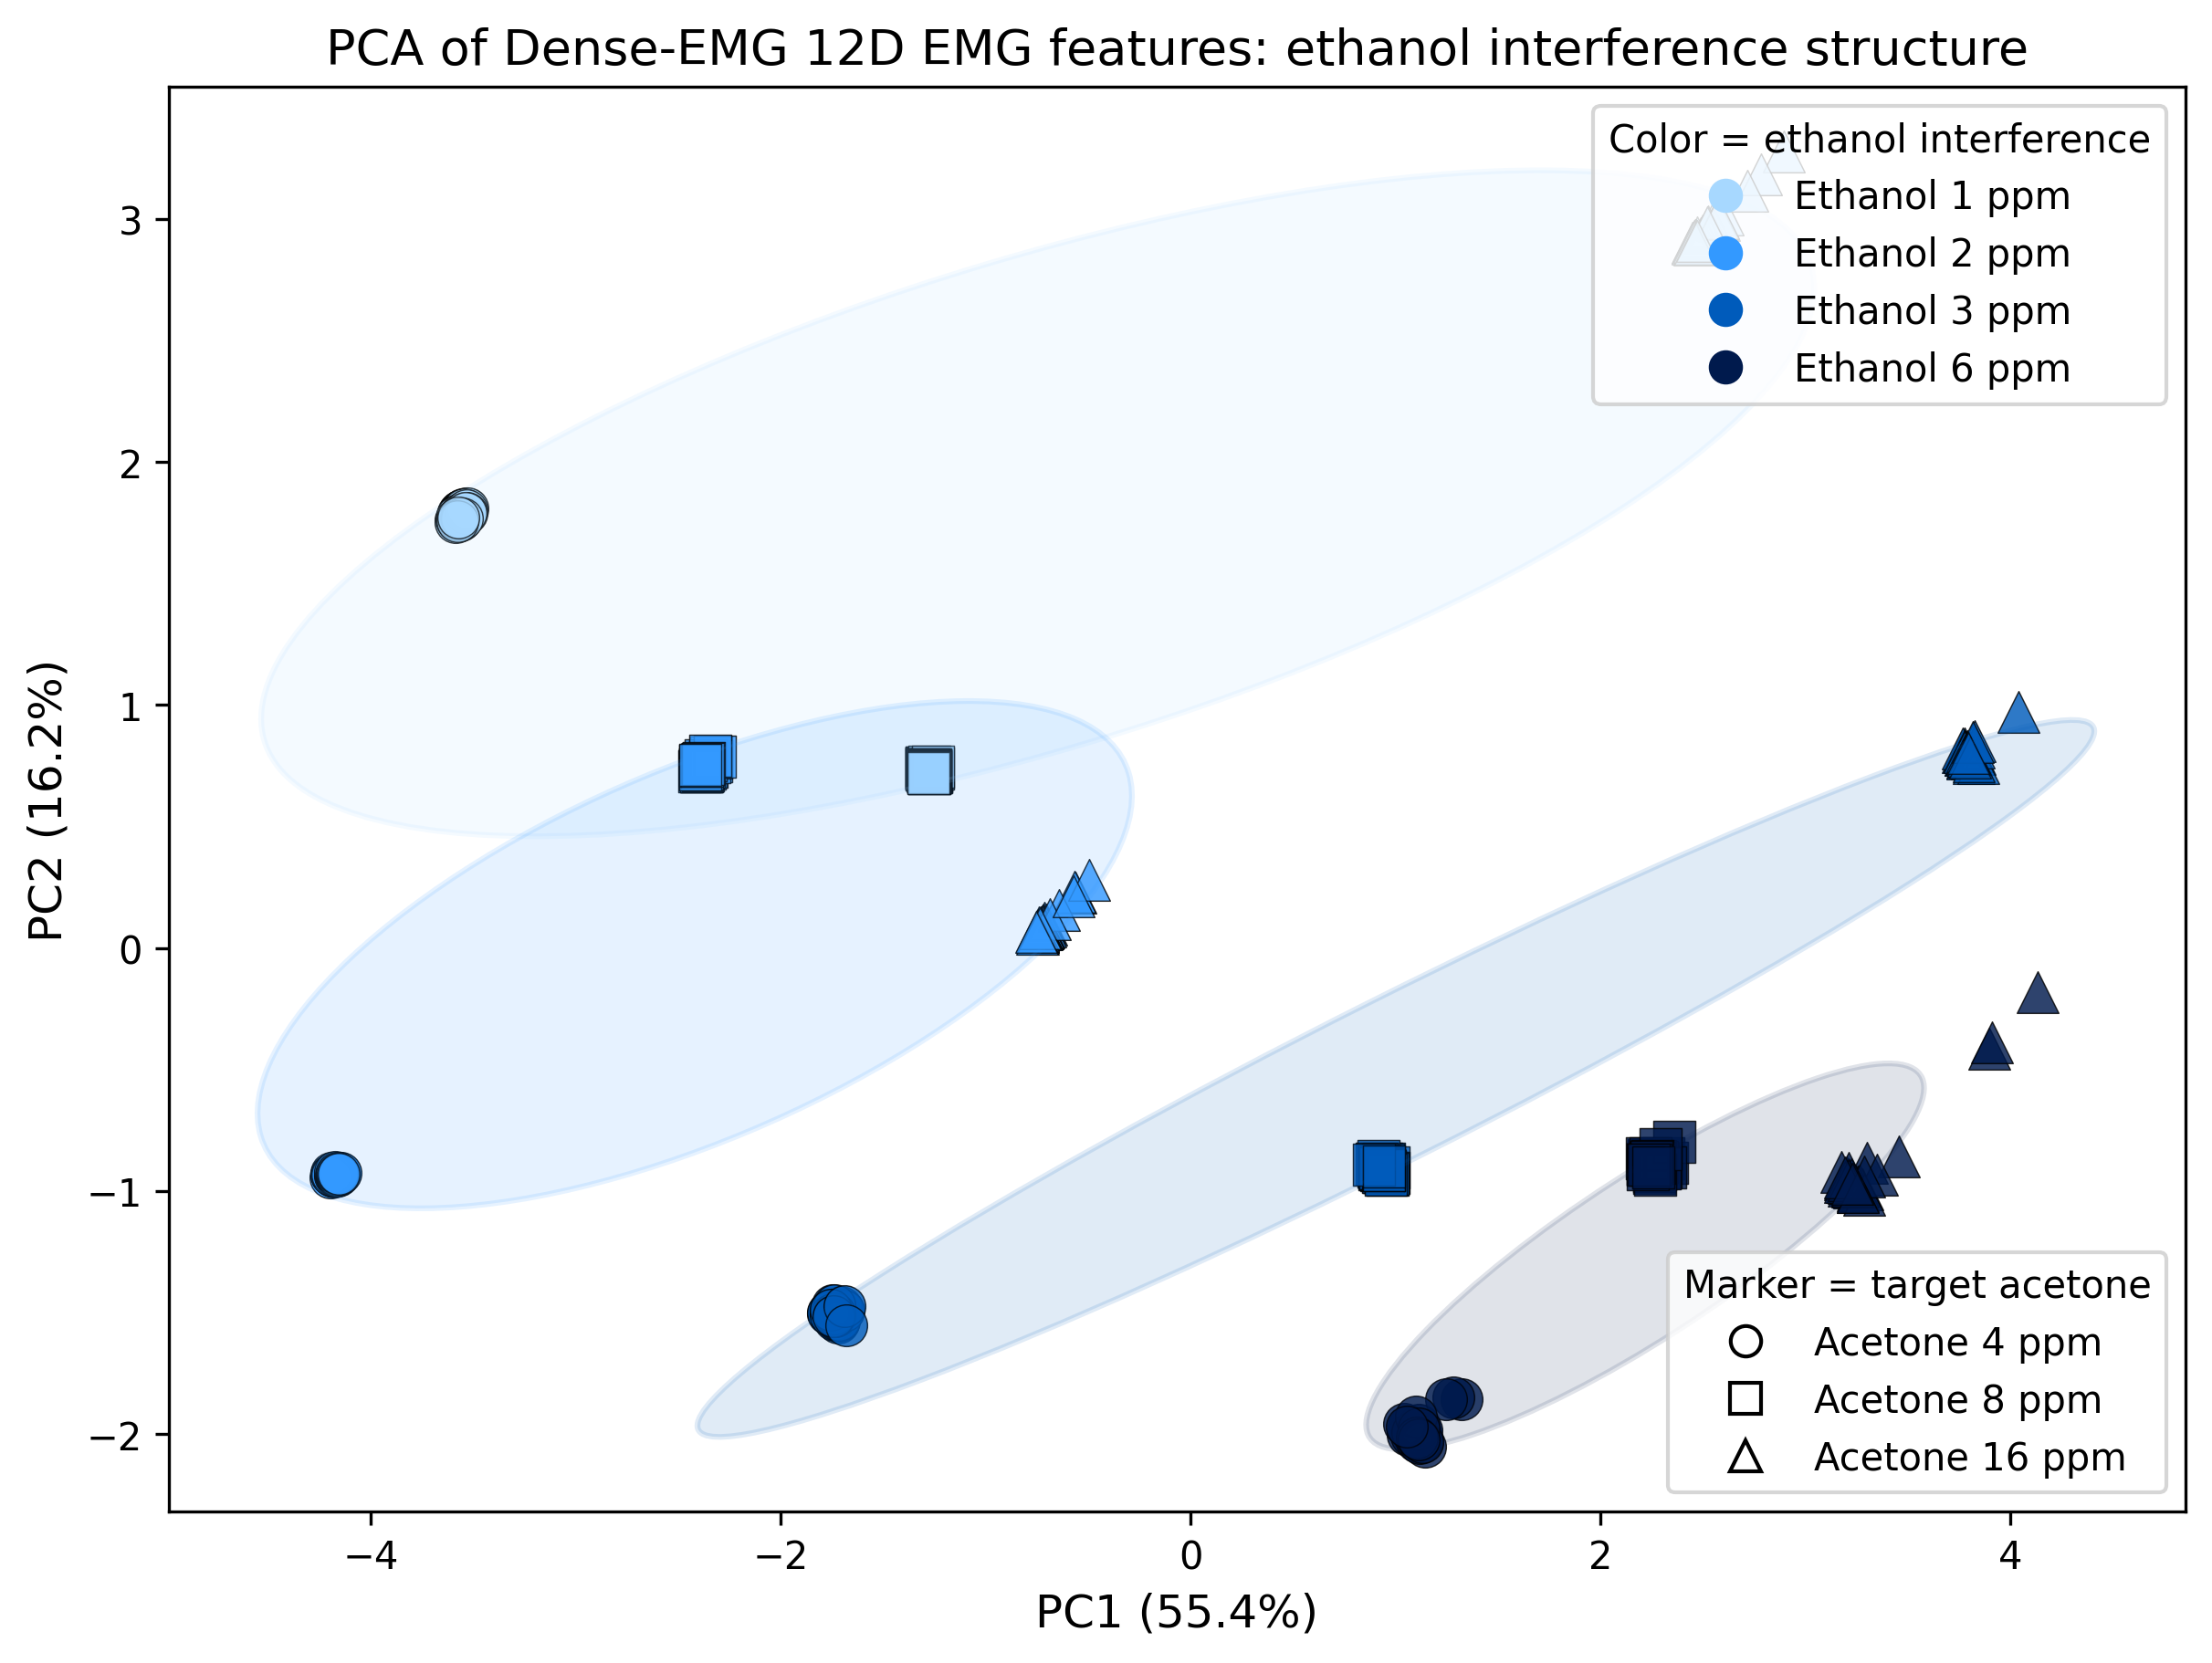

In [13]:
from IPython.display import Image, display

plot_file = "/content/MIXTURE_PCA_2D_ethanol_color_acetone_marker_clean.png"

display(Image(filename=plot_file))